<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
## Write your code here
# Display dataset structure, column types, and memory usage
print("--- Dataset Information ---")
df.info()


--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here
# Count missing values for each column
missing_values = df.isnull().sum()
print("--- Missing Values Count Per Column ---")
print(missing_values)


--- Missing Values Count Per Column ---
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



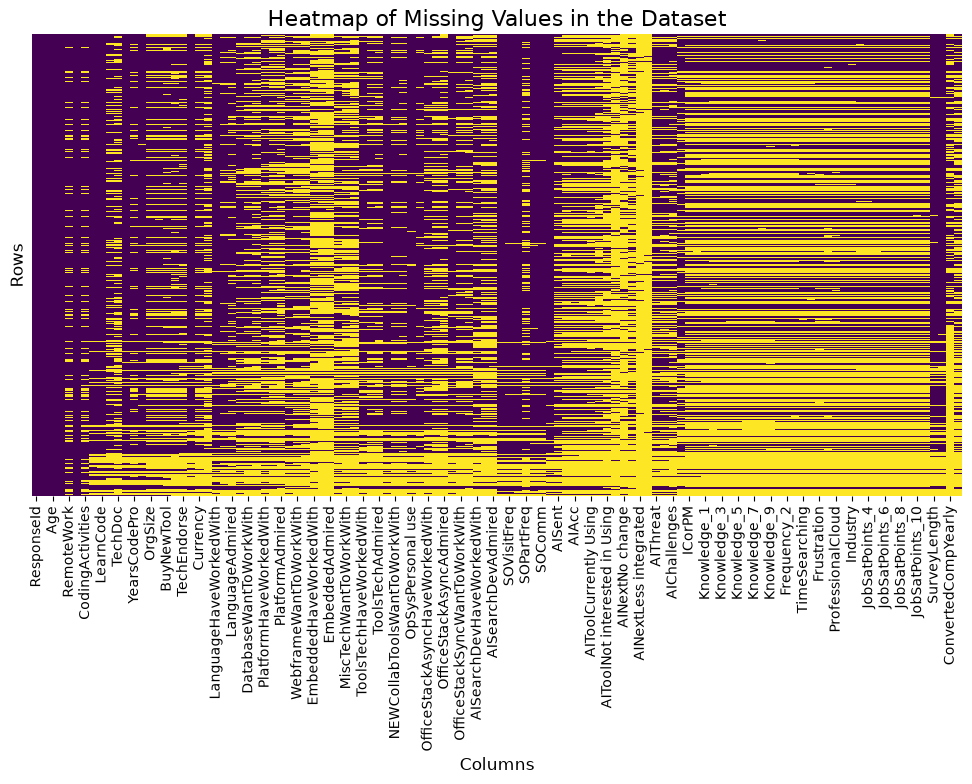

In [6]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(12, 6))

# Create the heatmap
# yticklabels=False hides row numbers for a cleaner look
# cbar=False removes the color bar legend since it's just True/False
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

# Add titles and labels
plt.title('Heatmap of Missing Values in the Dataset', fontsize=16)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)

# Display the plot
plt.show()


##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [ ]:
## Write your code here

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [7]:
## Write your code here
# Find the most frequent value (mode)
employment_mode = df['Employment'].mode()[0]
print(f"The most frequent value in the 'Employment' column is: {employment_mode}")


The most frequent value in the 'Employment' column is: Employed, full-time

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [9]:
# 1. Calculate the mode string safely
employment_mode = df['Employment'].mode()[0]

# 2. Reassign the result back to the column (No inplace required)
df['Employment'] = df['Employment'].fillna(employment_mode)

# 3. Verify
print(f"Missing values left in 'Employment': {df['Employment'].isnull().sum()}")


Missing values left in 'Employment': 0

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


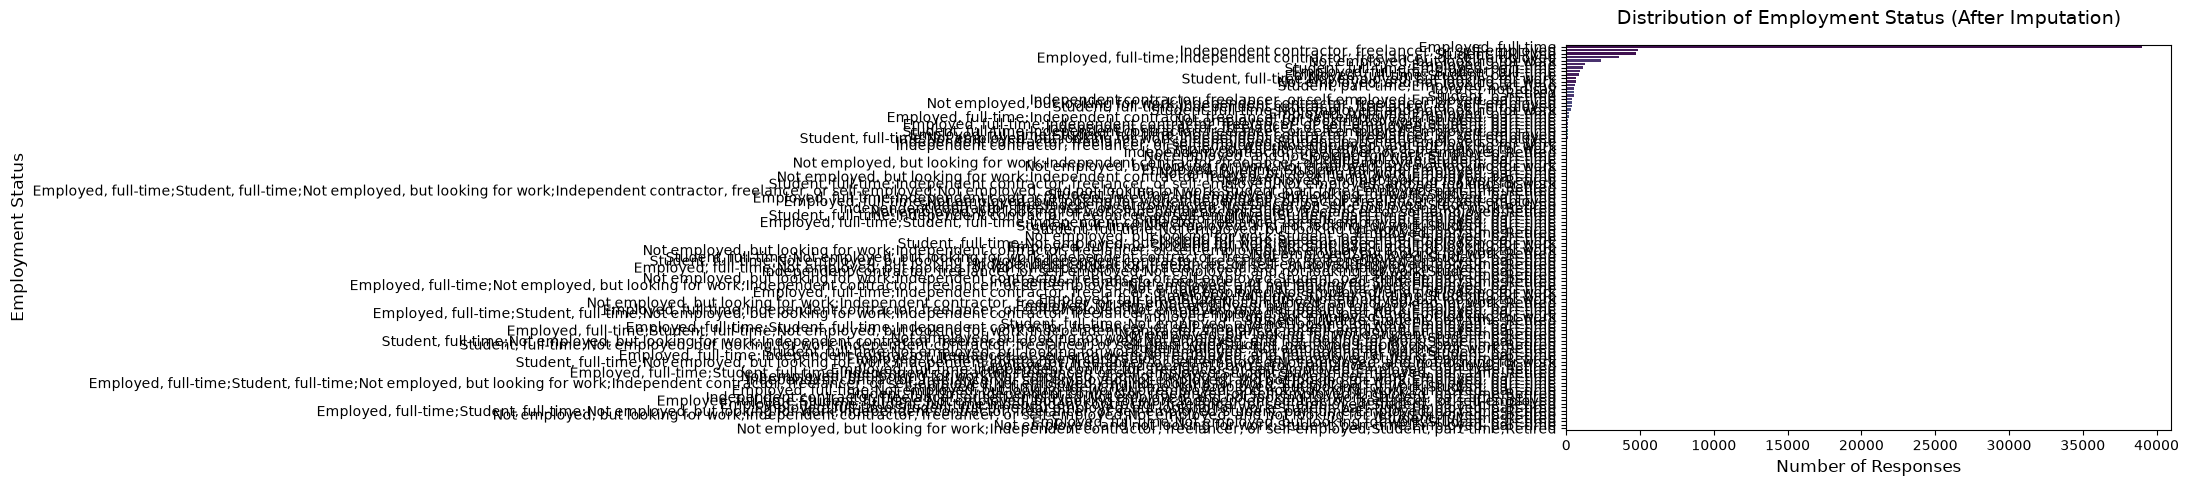

In [12]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Increase the figure width slightly to provide more breathing room for long text
plt.figure(figsize=(11, 5))

# Create the count plot with modern Seaborn styling
sns.countplot(
    data=df, 
    y='Employment', 
    hue='Employment',                         # Fixes the palette deprecation warning
    order=df['Employment'].value_counts().index, 
    palette='viridis',
    legend=False                              # Prevents a redundant legend box from appearing
)

# Clear and descriptive formatting
plt.title('Distribution of Employment Status (After Imputation)', fontsize=14, pad=15)
plt.xlabel('Number of Responses', fontsize=12)
plt.ylabel('Employment Status', fontsize=12)

# Adjust padding using subplots_adjust to safely handle extra-long left text labels
plt.subplots_adjust(left=0.35)

# Display the plot safely
plt.show()



### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
